# Fase 2 - TECH CHALLENGE
Case Classificando a qualidade de vinhos com Machine Learning

In [93]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o dataset
df = pd.read_csv("../data/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [94]:
# Exibe dados iniciais do DataFrame
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


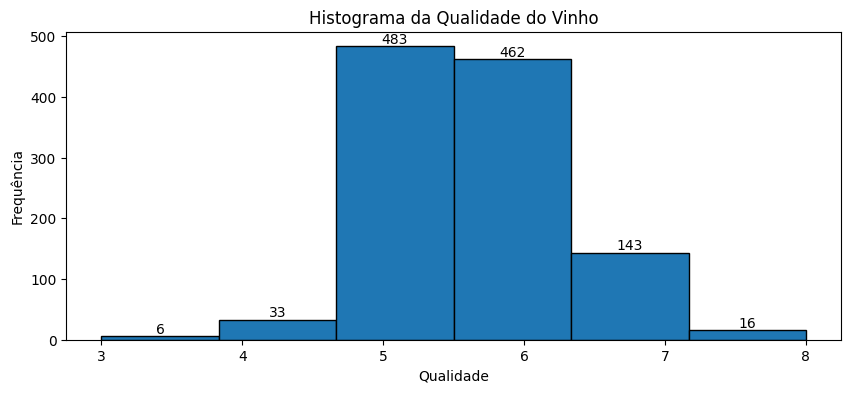

In [95]:
# Histograma da variável quality
plt.figure(figsize=(10, 4))
counts, bins, patches = plt.hist(df['quality'], bins=6, edgecolor='black')
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width() / 2,
        count,
        int(count),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )
plt.title('Histograma da Qualidade do Vinho')
plt.xlabel('Qualidade')
plt.ylabel('Frequência')
plt.show()

# Investigação da distribuição das variáveis
A seguir, são exibidas as estatísticas descritivas e os histogramas de todas as variáveis numéricas do dataset.

In [96]:
# Criar coluna categórica para teste de qualidade
df['teste_qualidade'] = np.where(df['quality'] >= 7, 1, 0)

In [97]:
# Verificar distribuição da variável teste_qualidade criada
print("\nDistribuição da coluna teste_qualidade:")
print(df['teste_qualidade'].value_counts())


Distribuição da coluna teste_qualidade:
teste_qualidade
0    984
1    159
Name: count, dtype: int64


In [98]:
#Exibe informações do DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
 13  teste_qualidade       1143 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 125.1 KB


O conjunto de dados possui 1.143 registros (linhas) e 14 atributos (colunas).

Observa-se que todas as colunas possuem 1.143 valores não nulos, indicando que não há valores ausentes (missing values) no dataset. Isso reduz a necessidade de tratamentos de imputação ou exclusão de registros durante a etapa de pré-processamento.

Estatísticas descritivas das variáveis numéricas:



,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


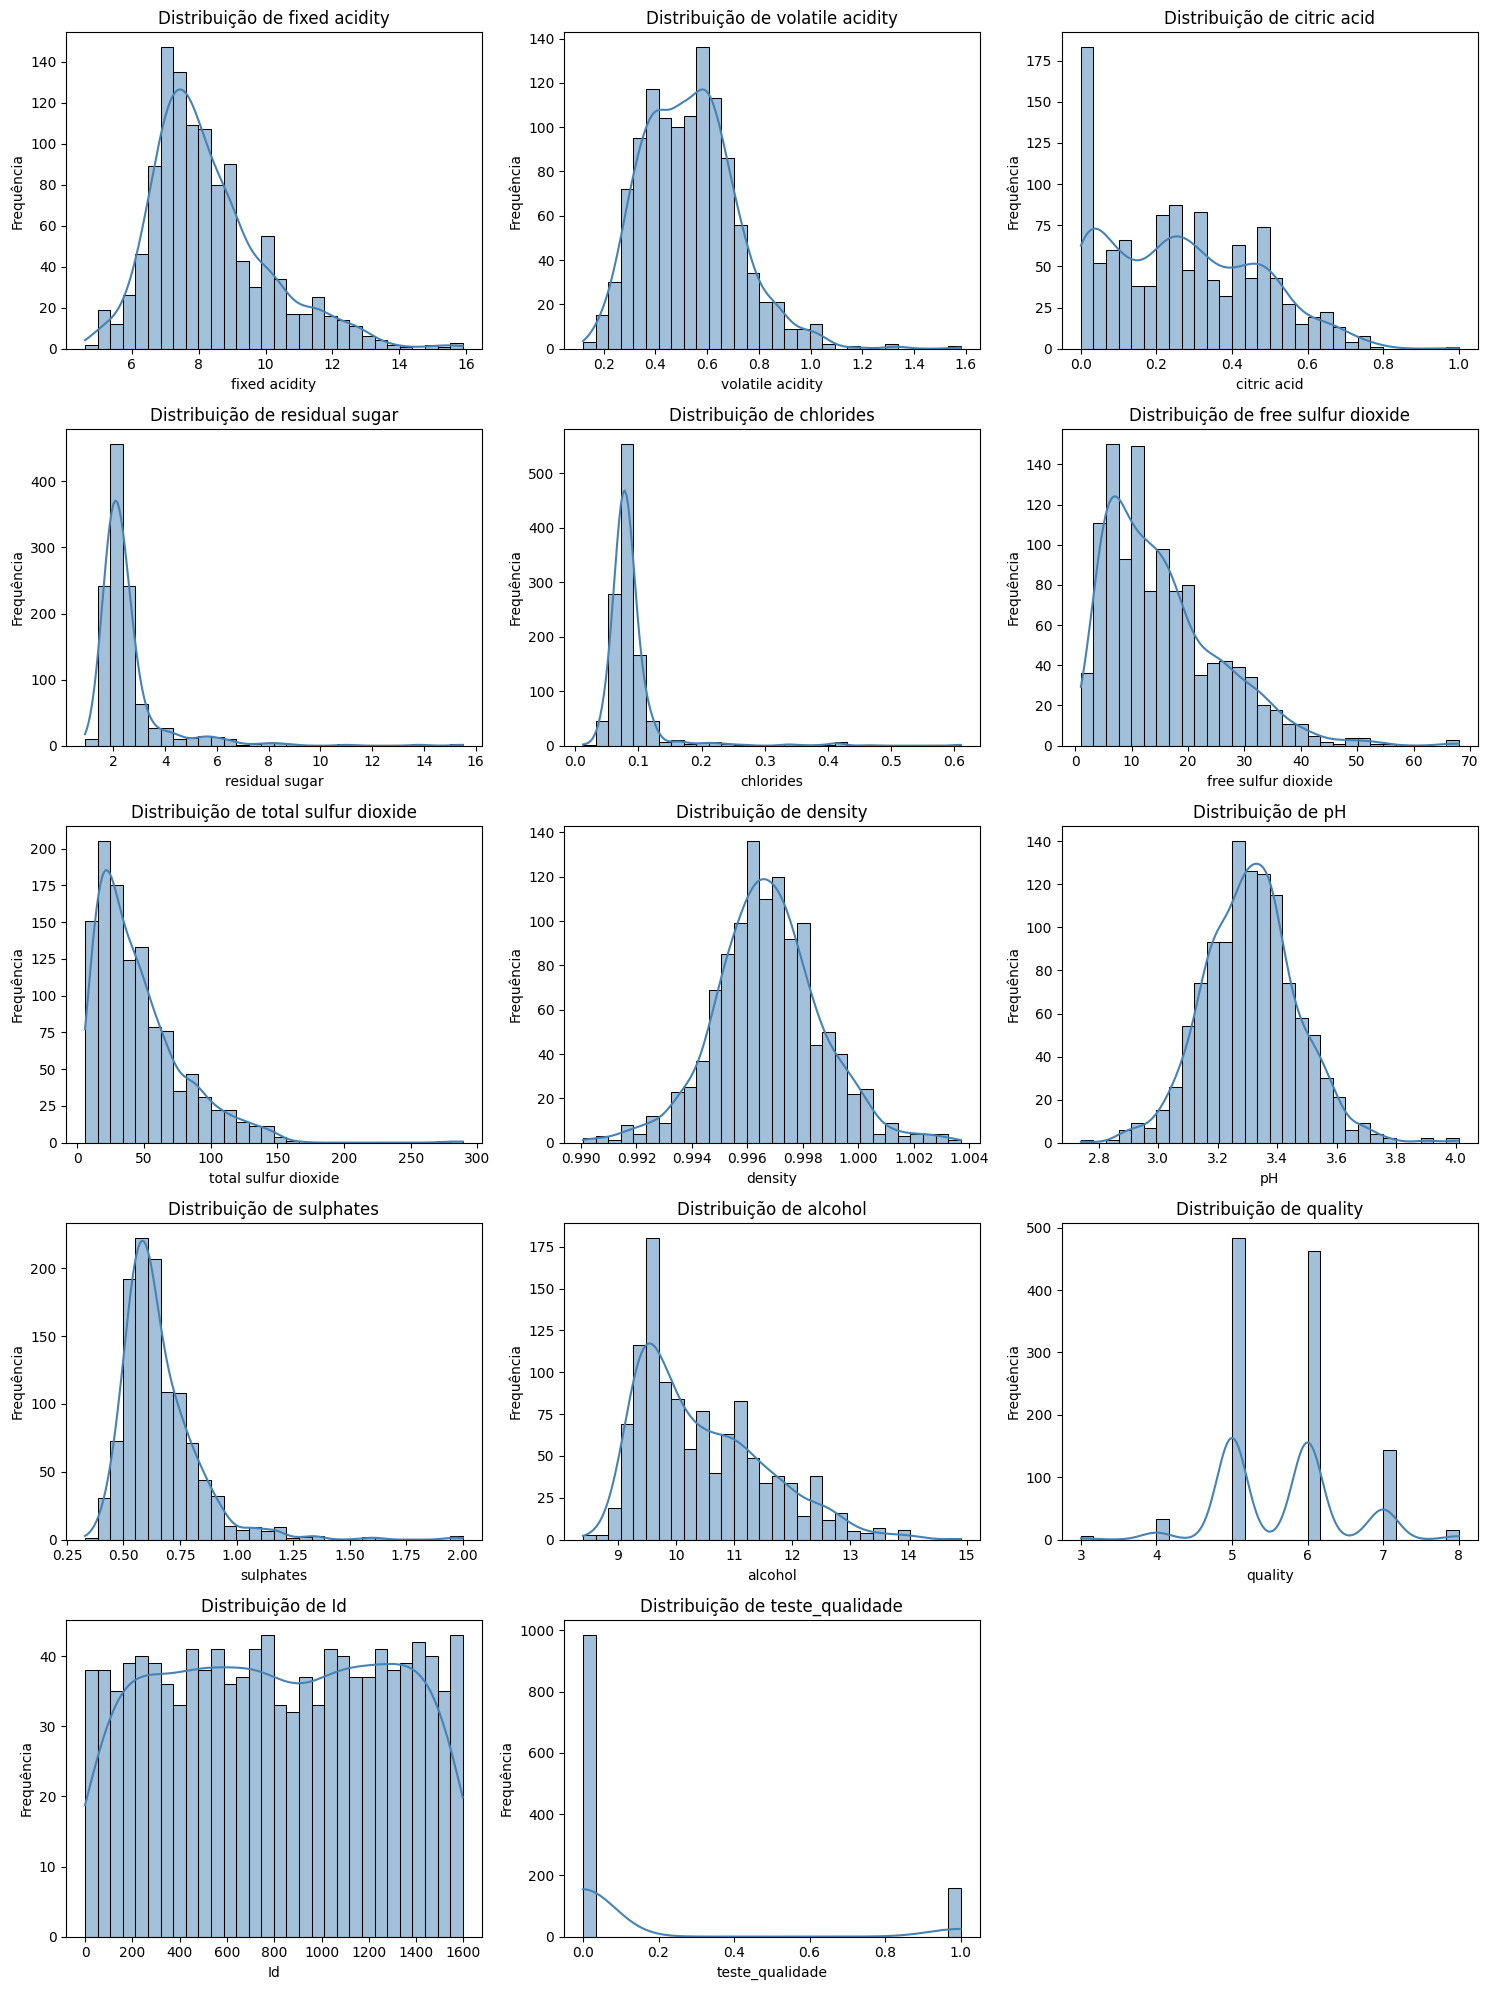

In [99]:
# Análise de distribuição das variáveis numéricas
df_numeric = df.select_dtypes(include=[np.number])
print("Estatísticas descritivas das variáveis numéricas:\n")
display(df_numeric.describe().T)

# Histogramas para cada variável numérica
num_cols = df_numeric.columns.tolist()
cols = 3
rows = int(np.ceil(len(num_cols) / cols))
plt.figure(figsize=(cols * 5, rows * 4))
for i, col in enumerate(num_cols, start=1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()



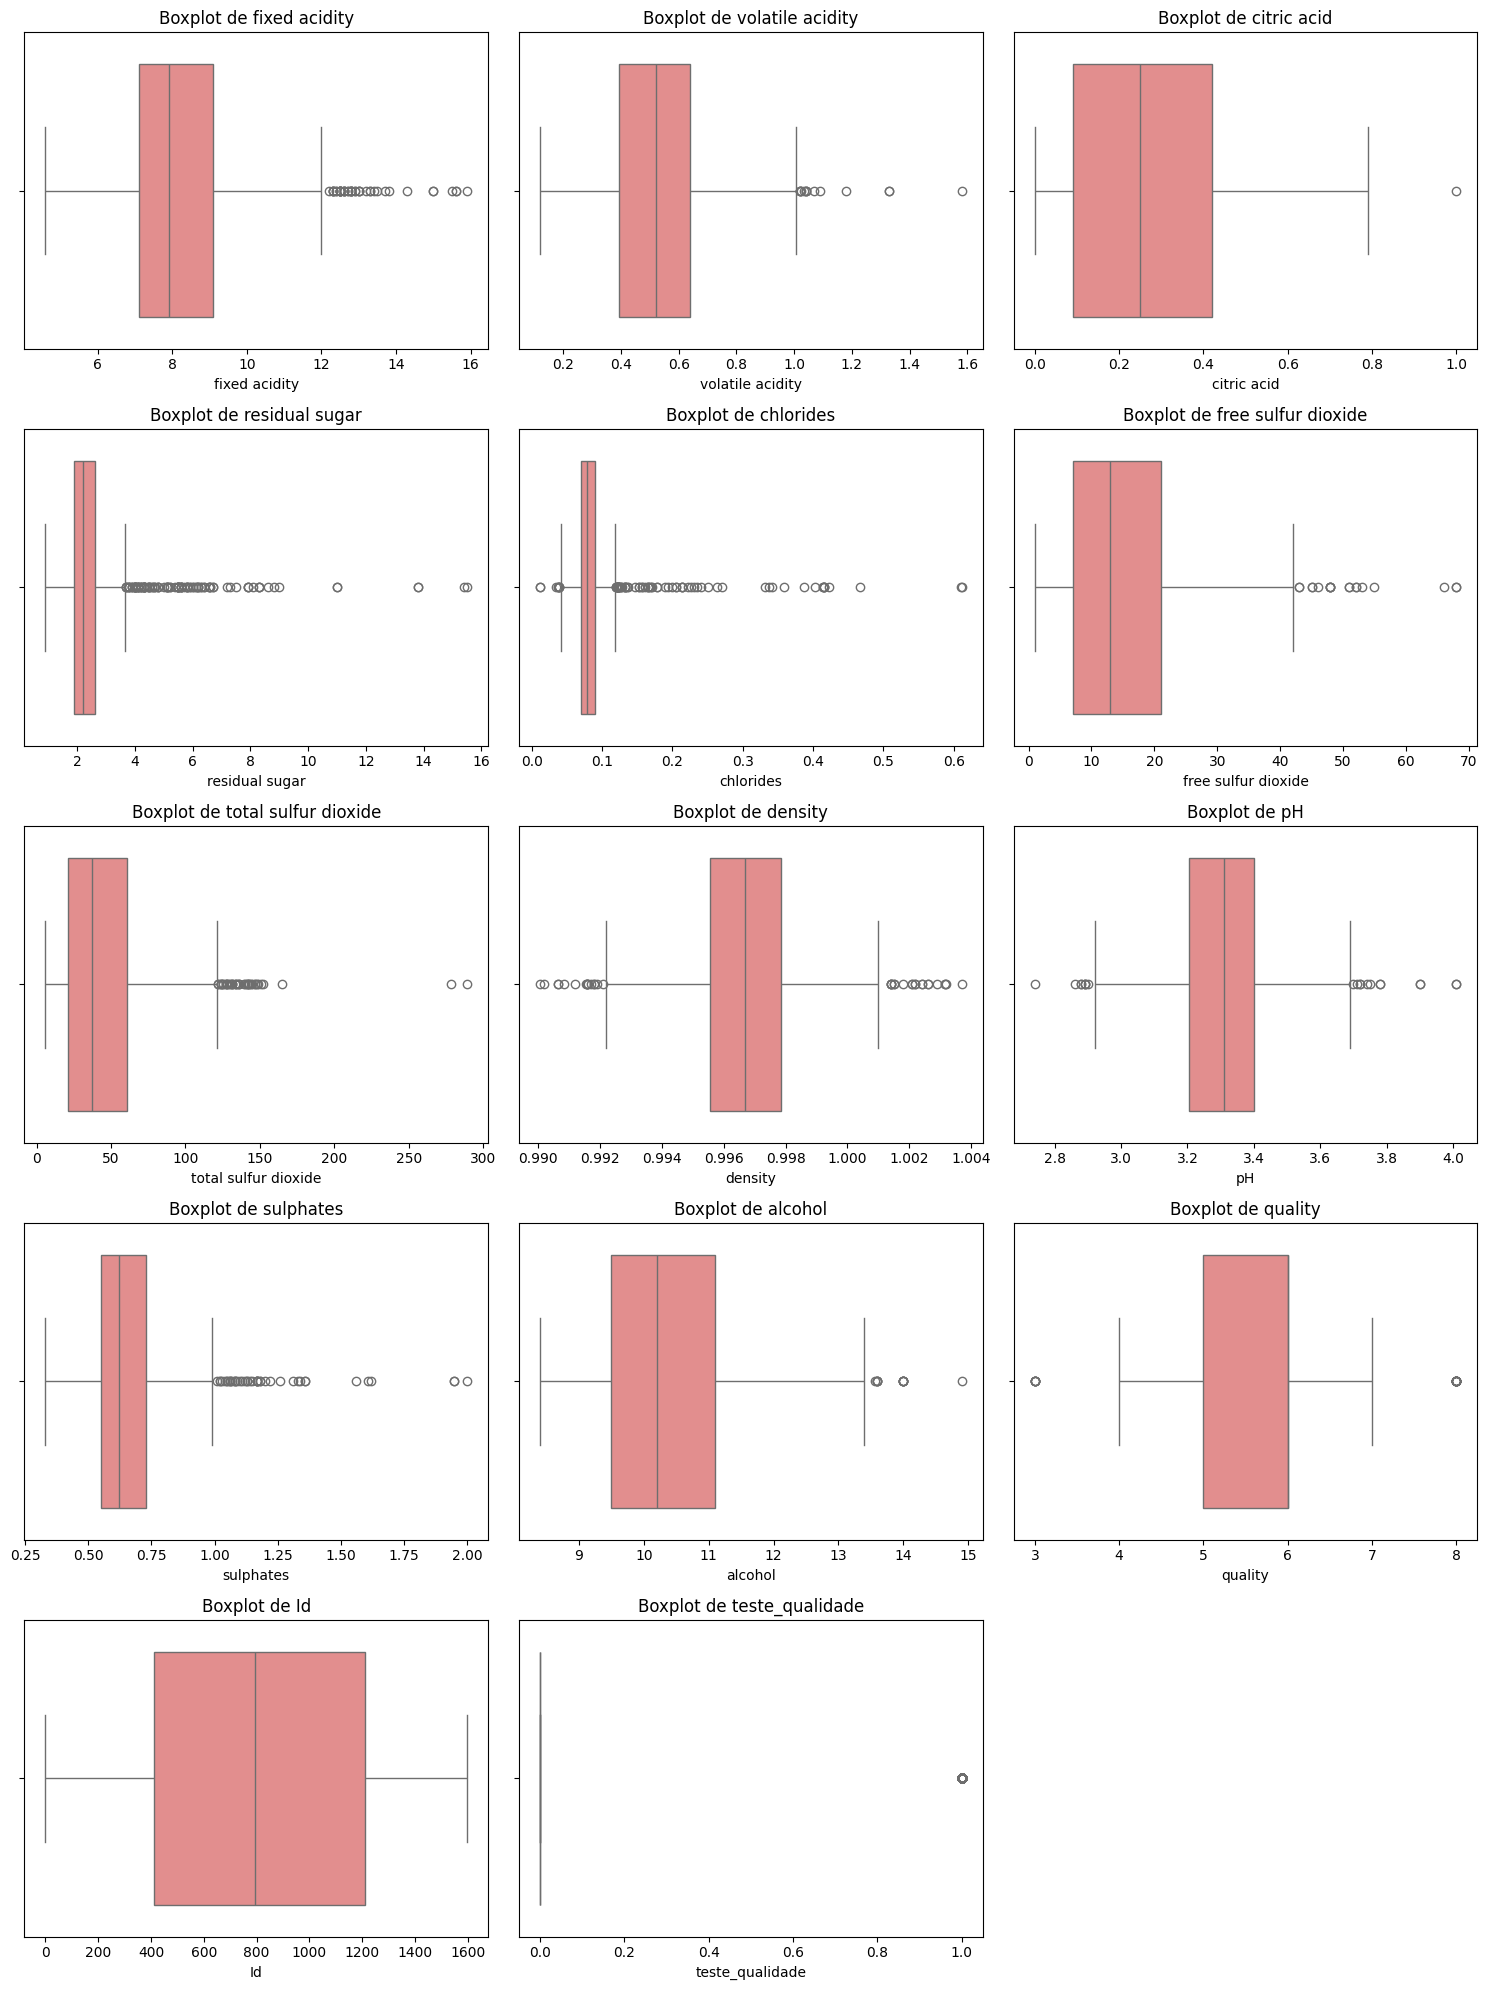

In [100]:
# Boxplots para variáveis numéricas
plt.figure(figsize=(cols * 5, rows * 4))
for i, col in enumerate(num_cols, start=1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

# Correlação das variáveis

Correlação das variáveis com teste_qualidade:


,teste_qualidade
quality,0.720433
alcohol,0.403676
citric acid,0.251146
sulphates,0.208020
fixed acidity,0.123212
residual sugar,0.064145
Id,0.019165
free sulfur dioxide,-0.055977
pH,-0.073318
chlorides,-0.103985


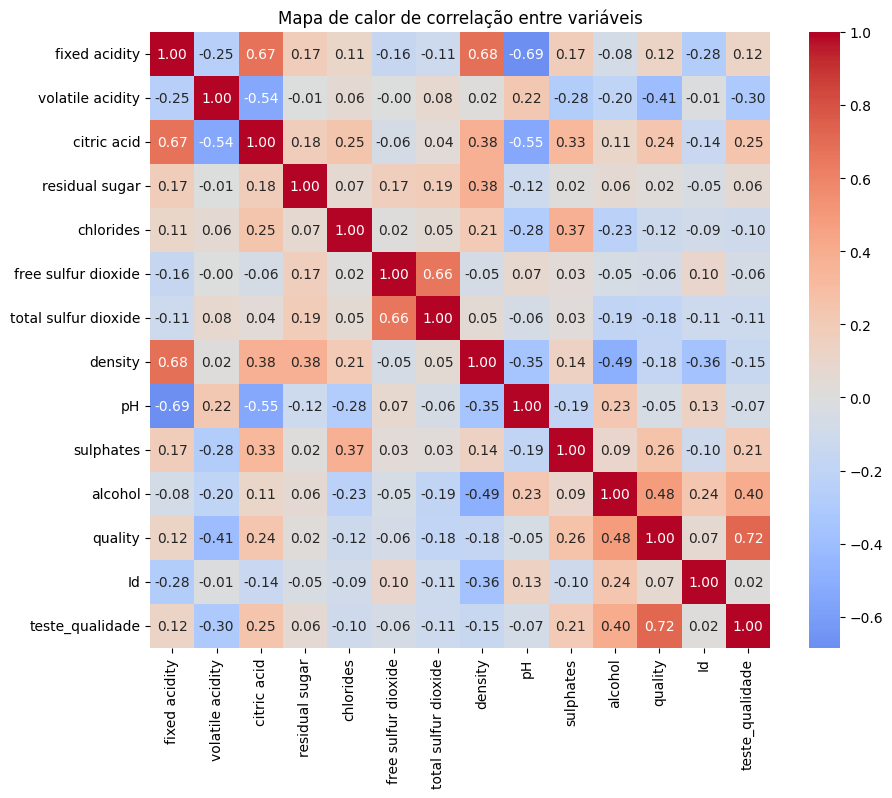

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_9532\2237304095.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr['teste_qualidade'].abs(), y=target_corr.index, palette='viridis')


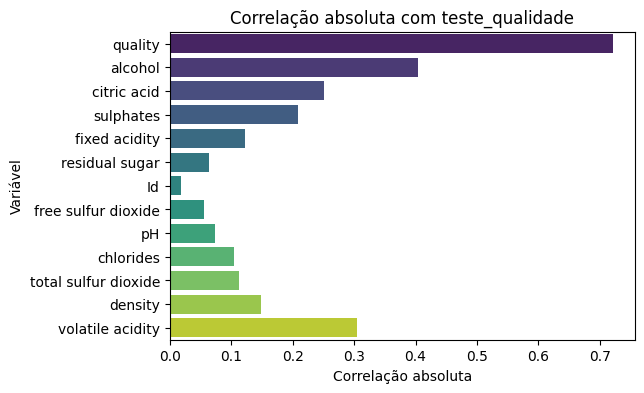

In [106]:
# Mapa de calor de correlação com a variável alvo teste_qualidade
corr = df.corr()
target_corr = corr[['teste_qualidade']].drop(index='teste_qualidade').sort_values(by='teste_qualidade', ascending=False)
print('Correlação das variáveis com teste_qualidade:')
display(target_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de calor de correlação entre variáveis')
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(x=target_corr['teste_qualidade'].abs(), y=target_corr.index, palette='viridis')
plt.title('Correlação absoluta com teste_qualidade')
plt.xlabel('Correlação absoluta')
plt.ylabel('Variável')
plt.show()

# DecisionTreeClassifier

In [105]:
# Separar % da base para teste e treinar com árvore de decisão
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Usar as variáveis de entrada sem a coluna de qualidade e sem a variável alvo criada
X = df.drop(columns=['Id', 'quality', 'teste_qualidade'])
y = df['teste_qualidade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Treinar o modelo
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Avaliar o modelo
y_pred = model.predict(X_test)
print('Acurácia no conjunto de teste:', accuracy_score(y_test, y_pred))
print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred))



Acurácia no conjunto de teste: 0.8895348837209303

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       148
           1       0.59      0.67      0.63        24

    accuracy                           0.89       172
   macro avg       0.77      0.80      0.78       172
weighted avg       0.90      0.89      0.89       172



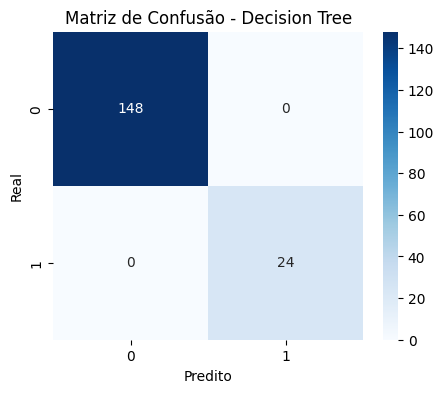


Importância das variáveis:
quality                 1.0
fixed acidity           0.0
citric acid             0.0
volatile acidity        0.0
residual sugar          0.0
chlorides               0.0
total sulfur dioxide    0.0
free sulfur dioxide     0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
dtype: float64


In [104]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Decision Tree')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# Importância das variáveis
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('\nImportância das variáveis:')
print(importances)

# Logistic Regression

In [ ]:
# Logistic Regression com normalização dos dados
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Normalizar os dados (importante para Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treinar o modelo de Regressão Logística
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

# Avaliar o modelo
y_pred_lr = model_lr.predict(X_test_scaled)
print('Acurácia no conjunto de teste:', accuracy_score(y_test, y_pred_lr))
print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred_lr))


In [ ]:
# Matriz de confusão - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Logistic Regression')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# Coeficientes do modelo (importância relativa de cada variável)
coeficients = pd.Series(model_lr.coef_[0], index=X.columns).sort_values(ascending=False)
print('\nCoeficientes das variáveis (peso de cada feature):')
print(coeficients)
